In [1]:
# ===== Section 4 (SiCoE) vs OFUL + Sparsity ID % (right/wrong) =====
# Environment is generated OUTSIDE and passed in; plotting is OUTSIDE the runners.

import numpy as np
import math
import matplotlib.pyplot as plt

# ----------------- Environment (outside) -----------------
def dual_q(p: float) -> float:
    if p <= 1:
        raise ValueError("p must be > 1")
    return p / (p - 1.0)

def generate_sparse_theta(d: int, s: int, p: float, seed: int = 0):
    """
    Return (theta_star, true_support) with ||theta_star||_q = 1, q = p/(p-1).
    """
    rng = np.random.default_rng(seed)
    q = dual_q(p)
    idx = rng.choice(d, size=s, replace=False)
    theta = np.zeros(d)
    signs = rng.choice([-1.0, 1.0], size=s)
    theta[idx] = signs * (0.5 + 0.5*rng.random(s))
    qn = np.power(np.sum(np.abs(theta)**q), 1.0/q)
    if qn > 0:
        theta = theta / qn
    return theta, set(idx.tolist())

# ----------------- Linear oracle + OFUL greedy action (FW) -----------------
def _lp_linear_oracle(g: np.ndarray, p: float, radius: float) -> np.ndarray:
    q = dual_q(p)
    g = np.asarray(g, dtype=float)
    if np.allclose(g, 0.0):
        return np.zeros_like(g)
    abs_g = np.abs(g)
    g_q = np.power(np.sum(abs_g**q), 1.0/q)
    if g_q == 0.0:
        return np.zeros_like(g)
    pow_exp = q - 1.0
    return radius * np.sign(g) * (abs_g**pow_exp) / (g_q**pow_exp)

def _oful_greedy_action_lp(u: np.ndarray,
                           V_inv: np.ndarray,
                           p: float,
                           beta: float,
                           radius: float = 1.0,
                           iters: int = 20,
                           rng: np.random.Generator | None = None) -> np.ndarray:
    """
    Approx. maximize <u,a> + beta*sqrt(a^T V_inv a) over ||a||_p <= radius via Frank–Wolfe.
    Warm-start on boundary ensures nonzero first step even if u ≈ 0.
    """
    u = np.asarray(u, dtype=float)
    V_inv = np.asarray(V_inv, dtype=float)
    V_inv = 0.5*(V_inv + V_inv.T)
    d = u.shape[0]
    rng = np.random.default_rng() if rng is None else rng

    g0 = u if not np.allclose(u, 0.0) else rng.standard_normal(d)
    a = _lp_linear_oracle(g0, p=p, radius=radius)

    eps = 1e-12
    for k in range(iters):
        Va = V_inv @ a
        quad = float(a @ Va)
        if quad <= eps:
            g = (u if not np.allclose(u, 0.0) else V_inv @ rng.standard_normal(d))
        else:
            g = u + (beta * Va) / (2.0 * math.sqrt(quad))
        s = _lp_linear_oracle(g, p=p, radius=radius)
        gamma = 2.0 / (k + 2.0)
        a = (1.0 - gamma) * a + gamma * s
    return a

# ----------------- Baseline: OFUL (dense) -----------------
def run_oful_dense_experiment(theta_star: np.ndarray,
                              p: float,
                              T: int,
                              reps: int = 20,
                              sigma: float = 1.0,
                              lam: float = 1.0,
                              fw_iters: int = 20,
                              seed: int = 2025,
                              beta_scale: float = 1.0,
                              beta_mode: str = "sqrtlog"):
    d = theta_star.shape[0]
    q = dual_q(p)
    curves = []

    for k in range(reps):
        rng = np.random.default_rng(seed + 17*k)
        V = lam * np.eye(d)
        b = np.zeros(d)
        regret = np.zeros(T)
        cum_regret = 0.0
        theta_q = np.power(np.sum(np.abs(theta_star)**q), 1.0/q)

        for t in range(1, T+1):
            try:
                V_inv = np.linalg.inv(V)
            except np.linalg.LinAlgError:
                V_inv = np.linalg.pinv(V)
            theta_hat = V_inv @ b

            beta_t = beta_scale * math.sqrt(d * math.log(max(t, 2))) if beta_mode=="sqrtlog" else beta_scale
            a_t = _oful_greedy_action_lp(theta_hat, V_inv, p=p, beta=beta_t,
                                         radius=1.0, iters=fw_iters, rng=rng)

            noise = rng.normal(0.0, sigma)
            r_t = float(a_t @ theta_star + noise)

            inst_regret = theta_q - float(a_t @ theta_star)
            cum_regret += inst_regret
            regret[t-1] = cum_regret

            V += np.outer(a_t, a_t)
            b += a_t * r_t

        curves.append(regret)

    curves = np.array(curves)
    mean_reg = curves.mean(axis=0)
    std_reg  = curves.std(axis=0)
    return mean_reg, std_reg, curves

# ----------------- Section 4 Algorithm (SiCoE-style) + ID % metrics -----------------
def run_sicoe_experiment(theta_star: np.ndarray,
                         true_support: set,
                         s: int,
                         p: float,
                         T: int,
                         reps: int = 20,
                         sigma: float = 1.0,
                         lam: float = 1.0,
                         fw_iters: int = 15,
                         seed: int = 2025,
                         beta_scale: float = 1.0):
   
    d = theta_star.shape[0]
    q = dual_q(p)

    curves = []
    right_pct_all = []
    wrong_pct_all = []

    for k in range(reps):
        rng = np.random.default_rng(seed + 19*k)
        theta_q = np.power(np.sum(np.abs(theta_star)**q), 1.0/q)

        St = set()
        B_sq_sum = 0.0
        Ar_sum = np.zeros(d)

        V_S = None
        b_S = None

        regret = np.zeros(T)
        cum_regret = 0.0

        for t in range(1, T+1):
            # Exploration budget
            
            B_t = min(((s**q) * (d**-1.0) * (t**-0.5))**(1.0/(p+1.0)),d**(-1.0/p))
    #        print(B_t)
            A = np.zeros(d)

            # Explore on unidentified coordinates
            Sc = [i for i in range(d) if i not in St]
            for i in Sc:
                A[i] = B_t * (1.0 if rng.random() < 0.5 else -1.0)

            # Remaining radius for exploitation on St
            Rt_p = 1.0 - len(Sc) * (B_t**p)
            if Rt_p < 0.0: Rt_p = 0.0
            Rt = (Rt_p**(1.0/p)) if Rt_p > 0.0 else 0.0

            # Exploitation on St with OFUL objective
            if len(St) > 0 and Rt > 0.0:
                St_list = sorted(St)
                dimS = len(St_list)
                if (V_S is None) or (V_S.shape[0] != dimS):
                    V_S = lam * np.eye(dimS)
                    b_S = np.zeros(dimS)
                try:
                    V_S_inv = np.linalg.inv(V_S)
                except np.linalg.LinAlgError:
                    V_S_inv = np.linalg.pinv(V_S)
                theta_hat_S = V_S_inv @ b_S
                beta_t = beta_scale * math.sqrt(dimS * math.log(max(t, 2)))
                a_S = _oful_greedy_action_lp(theta_hat_S, V_S_inv, p=p, beta=beta_t,
                                             radius=Rt, iters=fw_iters, rng=rng)
                A[St_list] = a_S
                
            # Reward & regret
            noise = rng.normal(0.0, sigma)
            r_t = float(A @ theta_star + noise)
            inst_regret = theta_q - float(A @ theta_star)
            cum_regret += inst_regret
            regret[t-1] = cum_regret

            # Support ID updates
            B_sq_sum += B_t**2
            Ar_sum += A * r_t
            if B_sq_sum > 0.0:
                W_t = 4.0 * math.sqrt((1.0 / B_sq_sum) * max(1.0, math.log(max(t, 2))))
           #     print("W_t:", W_t)
                for i in Sc:
                    theta_tilde_i = Ar_sum[i] / B_sq_sum
       #             print("theta_tilde_i:", theta_tilde_i)
                    if 1.5*abs(theta_tilde_i) > W_t: #1.2
                        St.add(i)

            # Log percentages
            tp = len(St & true_support)
            fp = len(St - true_support)
            
            # OFUL stats on St
            if len(St) > 0:
                St_list = sorted(St)
                a_S = A[St_list]
                if (V_S is None) or (V_S.shape[0] != len(St_list)):
                    V_S = lam * np.eye(len(St_list))
                    b_S = np.zeros(len(St_list))
                V_S += np.outer(a_S, a_S)
                b_S += a_S * r_t

        curves.append(regret)
    curves = np.array(curves)
    mean_reg = curves.mean(axis=0); std_reg = curves.std(axis=0)

    print("Estimate support:", St)
    return (mean_reg, std_reg, curves)

In [2]:
# ----------------- EXAMPLE USAGE: env + plots outside -----------------
if __name__ == "__main__":
    # Generate fixed environment OUTSIDE
    d, s, p = 50, 1, 2
    theta_star, true_support = generate_sparse_theta(d=d, s=s, p=p, seed=123)
#    print("theta_star:",  theta_star)
    print("true_support", true_support)
    # Compare OFUL vs Section 4 algo
    T, reps = 40000, 10
    mean_oful, std_oful, _ = run_oful_dense_experiment(
        theta_star=theta_star, p=p, T=T, reps=reps,
        sigma=1.0, lam=1.0, fw_iters=20, seed=2025,
        beta_scale=1.0, beta_mode="sqrtlog"
    )

    (mean_sicoe, std_sicoe, _) = run_sicoe_experiment(
        theta_star=theta_star, true_support=true_support, s=s,
        p=p, T=T, reps=reps, sigma=1.0, lam=1.0, fw_iters=15,
        seed=4242, beta_scale=1.0
    )

true_support {0}
Estimate support: {0}


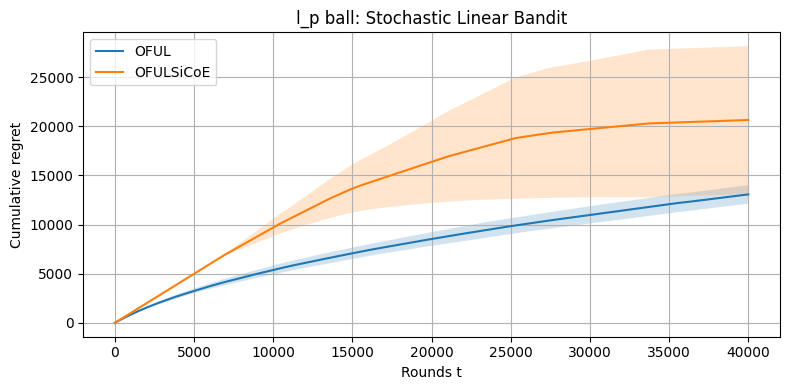

t:
[    1  4000  8000 12000 16000 20000 24000 28000 32000 36000 40000]

OFUL mean ± std:
1.02 ± 0.16
2742.78 ± 214.57
4588.75 ± 371.82
6099.62 ± 515.67
7396.34 ± 598.30
8532.38 ± 700.77
9596.09 ± 800.89
10540.08 ± 843.72
11425.29 ± 903.14
12280.11 ± 928.35
13069.76 ± 956.44

OFULSiCoE mean ± std:
1.00 ± 0.14
4000.39 ± 5.51
7886.25 ± 346.51
11373.02 ± 1460.43
14239.88 ± 2735.20
16382.08 ± 4179.80
18239.29 ± 5668.11
19415.92 ± 6680.63
20031.82 ± 7237.53
20419.94 ± 7510.80
20640.86 ± 7510.80


In [3]:
    # Plot regrets
    t = np.arange(1, T+1)
    plt.figure(figsize=(8,4))
    plt.plot(t, mean_oful, label="OFUL")
    plt.fill_between(t, mean_oful - std_oful, mean_oful + std_oful, alpha=0.2)
    plt.plot(t, mean_sicoe, label="OFULSiCoE")
    plt.fill_between(t, mean_sicoe - std_sicoe, mean_sicoe + std_sicoe, alpha=0.2)
    plt.xlabel("Rounds t"); plt.ylabel("Cumulative regret")
    plt.title(f"l_p ball: Stochastic Linear Bandit")
    plt.legend(); plt.tight_layout(); plt.grid(True); plt.savefig('LpBall2.png', dpi=300)
    plt.show();    

    # Print sampled regret values
    index_plot = np.linspace(0, T-1, num=11, dtype=int)
    
    print("t:")
    print(index_plot + 1)
    
    print("\nOFUL mean ± std:")
    for m, s in zip(mean_oful[index_plot], std_oful[index_plot]):
        print(f"{m:.2f} ± {s:.2f}")
    
    print("\nOFULSiCoE mean ± std:")
    for m, s in zip(mean_sicoe[index_plot], std_sicoe[index_plot]):
        print(f"{m:.2f} ± {s:.2f}")